# Pruebas

EL profesor en la clase mencionó cosas que nunca habia escuchado o trabajado. Dentro de una de las cosas que se me quedaron en la mente, fueron los colores en las imagenes, yo conocía y había trabajado previamente en matrices $n \times m \times 3$ para RGB, pero nunca me había puesto a pensar en otras opciones, como se mencionaron en clases.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Colores

Las que se mencionaron fueron:
* **RGB**. No lo trataré aquí, si acaso está [acá](./t00067699_tarea1.ipynb). Curiosamente, en opencv las imagenes están por defecto como BGR
* **HSV**.
* **CMYK**.
* **Hexadecimal**. Realmente es una conversión de cada uno de los colores RGB a hexadecimal, así `color = 0xrrggbb`, por lo que, solo haría falta utilizar un convertidor de decimal a hexadecimal (python provee uno llamado `hex()`). Básico quizás, pero fue bueno haberlo aclarado

In [19]:
COLORS = {
    "HSV": cv2.COLOR_BGR2HSV,
    "RGB": cv2.COLOR_BGR2RGB,
}

### HSV

Según lo que investigué, los colores en HSV tienen 3 variables: Hue [0, 179], Saturation [0, 255] y Value [0, 255]... así es al menos en opencv.

Veo una utilidad clave a utilizar HSV y es para la detección de color, lo cual me parece buenísimo

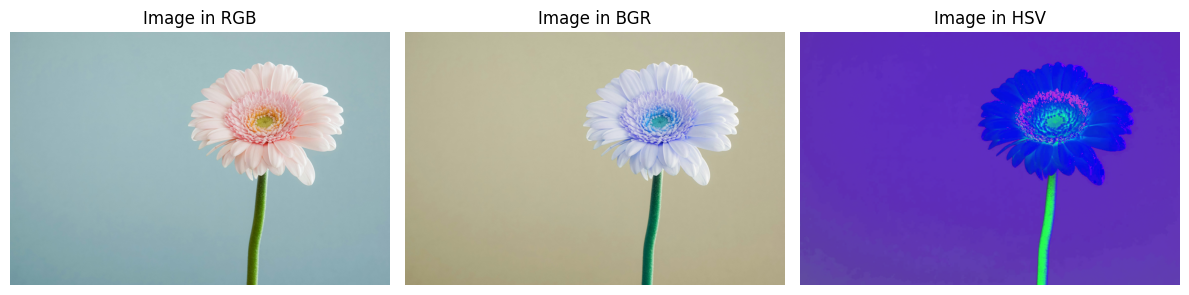

In [4]:
# Tomaré una de las imagenes que ya he descargado
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
image = cv2.imread("./images/flower_image.jpeg")

for color, ax in zip(["RGB", "BGR", "HSV"], axes):
    if color not in COLORS:
        ax.imshow(image)
    else:
        ax.imshow(cv2.cvtColor(image, COLORS[color]))
    ax.set_title(f"Image in {color}")
    ax.axis("off")

fig.tight_layout()
plt.show()

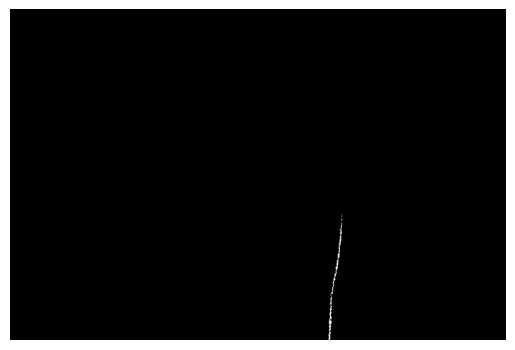

In [15]:
# Ahora, tomar solo lo verde de la imagen original
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
lower_green = np.array([40, 165, 140], np.uint8)
upper_green = np.array([102, 255, 255], np.uint8)

green_mask = cv2.inRange(image_hsv, lower_green, upper_green)

plt.imshow(green_mask, cmap="gray")
plt.axis("off")
plt.show()

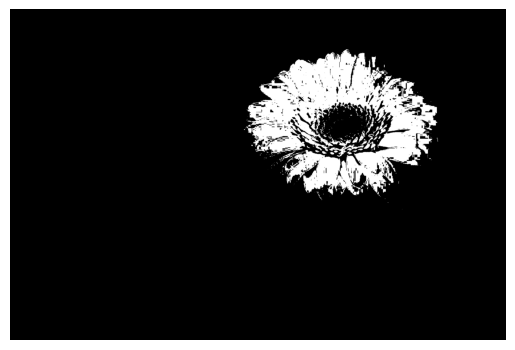

In [18]:
# Ahora solo tomar los pétalos
lower_pink1 = np.array([0, 12, 100], np.uint8)
upper_pink1 = np.array([10, 64, 255], np.uint8)

lower_pink2 = np.array([160, 12, 100], np.uint8)
upper_pink2 = np.array([179, 64, 255], np.uint8)

pink_mask1 = cv2.inRange(image_hsv, lower_pink1, upper_pink1)
pink_mask2 = cv2.inRange(image_hsv, lower_pink2, upper_pink2)
pink_mask = cv2.add(pink_mask1, pink_mask2)

plt.imshow(pink_mask, cmap="gray")
plt.axis("off")
plt.show()

### CMYK

Opencv no trabaja con la escala de color CMY/CMYK, pero aún así existen conversiones que se pueden hacer desde RGB.

**Para CMY**

$$C = 1 - R' = 1 - \frac{R}{255}$$
$$M = 1 - G' = 1 - \frac{G}{255}$$
$$Y = 1 - B' = 1 - \frac{B}{255}$$

**Para CMYK**

$$K = 1 - max\left( R', G', B' \right)$$
$$C = 1 - \frac{1-R'-K}{1-K}$$
$$M = 1 - \frac{1-G'-K}{1-K}$$
$$Y = 1 - \frac{1-B'-K}{1-K}$$


## Transformaciones

Existen demasiadas posibles transformaciones en una imagen, pero de las que se trataron en clase la primera semana, fueron las siguientes:

1. **Traslación**
2. **Escalamiento**
3. **Rotación**

### Traslaciones

Según la información de las diapositivas, se pueden hacer traslaciones en 2D en coordenadas homogeneas

$$P = (x, y)  \rightarrow (x, y, 1) $$
$$t = (t_x, t_y)  \rightarrow (t_x, t_y, 1) $$

$$
P'

\rightarrow

\begin{pmatrix}
    x + t_x  \\
    y + t_y  \\
    1
\end{pmatrix}

=

\begin{pmatrix}
    1 & 0 & t_x  \\
    0 & 1 & t_y  \\
    0 & 0 & 1
\end{pmatrix}
\cdot
\begin{pmatrix}
    x  \\
    y  \\
    1
\end{pmatrix}

=

\begin{pmatrix}
    I & t  \\
    0 & 1
\end{pmatrix}
\cdot
P

=

T \cdot P
$$


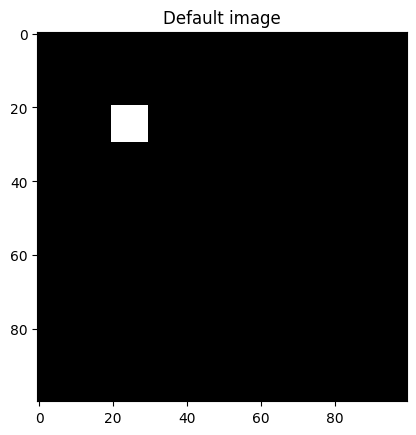

In [36]:
zeros = np.zeros((100, 100))
zeros[20:30, 20:30] = 255

plt.imshow(zeros, cmap="gray")
plt.title("Default image")
plt.show()

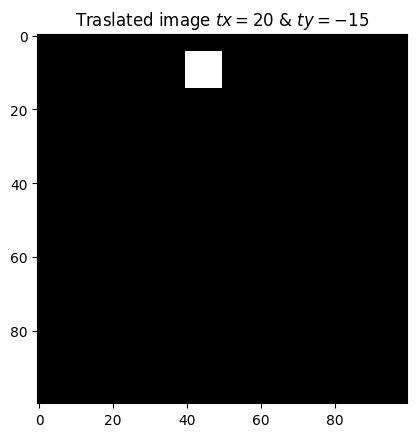

In [61]:
height, width = zeros.shape[:2]

tx, ty = 20, -15
T = np.array([[1, 0, tx], [0, 1, ty]], np.float32)
traslated = cv2.warpAffine(zeros, T, (width, height))

plt.imshow(traslated, cmap="gray")
plt.title(f"Traslated image ${tx=}$ & ${ty=}$")
plt.show()

### Escalación

En las diapositivas, la forma matricial del escalamiento es el siguiente:

$$P = (x, y) \rightarrow  P' = (s_xx, s_yy)$$
$$P = (x, y) \rightarrow (x, y, 1)$$
$$P' = (s_xx, s_yy) \rightarrow  P' = (s_xx, s_yy, 1)$$

$$
\begin{pmatrix}
    s_x x  \\
    s_y y  \\
    1
\end{pmatrix}

=

\begin{pmatrix}
    s_x & 0 & 0  \\
    0 & s_y & 0  \\
    0 & 0 & 1
\end{pmatrix}
\cdot
\begin{pmatrix}
    x  \\
    y  \\
    1
\end{pmatrix}

=

\begin{pmatrix}
    S' & 0  \\
    0 & 1
\end{pmatrix}
\cdot
P

=

S \cdot P
$$


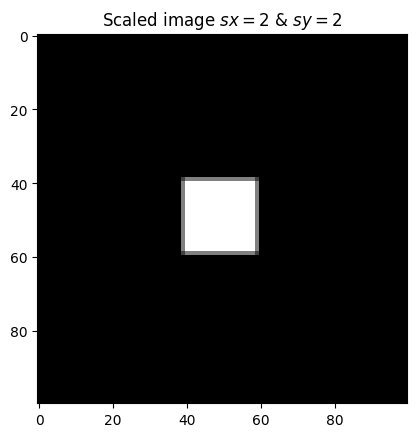

In [67]:
sx, sy = 2, 2
S = np.array([[sx, 0, 0], [0, sy, 0]], np.float32)
scaled = cv2.warpAffine(zeros, S, (width, height))

plt.imshow(scaled, cmap="gray")
plt.title(f"Scaled image ${sx=}$ & ${sy=}$")
plt.show()

### Rotaciones

Me gustaría hacer más pruebas con las rotaciones porque so bien entendí, quiero terminar de entenderlo bien, haciendo, precisamente, pruebas.

La matriz de rotación con respecto a un ángulo sale del siguiente sistema de ecuaciones.

$$x = R \cos{\left( \phi \right)}$$
$$y = R \sin{\left( \phi \right)}$$
$$x' = R \cos{\left( \phi + \theta \right)}$$
$$y' = R \sin{\left( \phi + \theta \right)}$$

Donde $R$, $\phi$ y $\theta$ son valores conocidos. Finalmente

$$x' = x \cos{\theta} - y \sin{\theta}$$
$$y' = x \sin{\theta} + y \cos{\theta}$$

O en forma matricial

$$
\begin{pmatrix}
  x' \\
  y'
\end{pmatrix}

=

\begin{pmatrix}
  \cos{\theta} && -\sin{\theta}  \\
  \sin{\theta} && \cos{\theta}
\end{pmatrix}
\begin{pmatrix}
  x \\
  y
\end{pmatrix}
$$

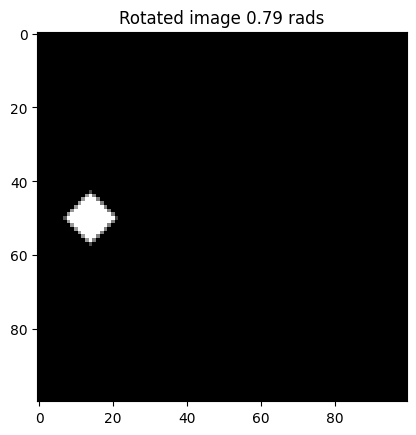

In [68]:
# Theta está en radianes
angle_rads = np.pi / 4

# Es prácticamente obligatorio siempre utilizar el centro de la imagen
R = cv2.getRotationMatrix2D((width / 2, height / 2), 45, 1)
rotated = cv2.warpAffine(zeros, R, (width, height))

plt.imshow(rotated, cmap="gray")
plt.title(f"Rotated image {angle_rads:.2f} rads")
plt.show()

## SVD

En la primera clase no se explicó SVD porque no nos compete, ese es tema de quienes estén haciendo magister, pero por lo mismo, me interesó probarlo un poco

In [4]:
u, s_diag, vt = np.linalg.svd(np.array([[1, 2, 3], [3, 4, 5], [6, 7, 8]]))
s = np.zeros((2, 3), dtype="float32")
np.fill_diagonal(s, s_diag)
